In [46]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [47]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


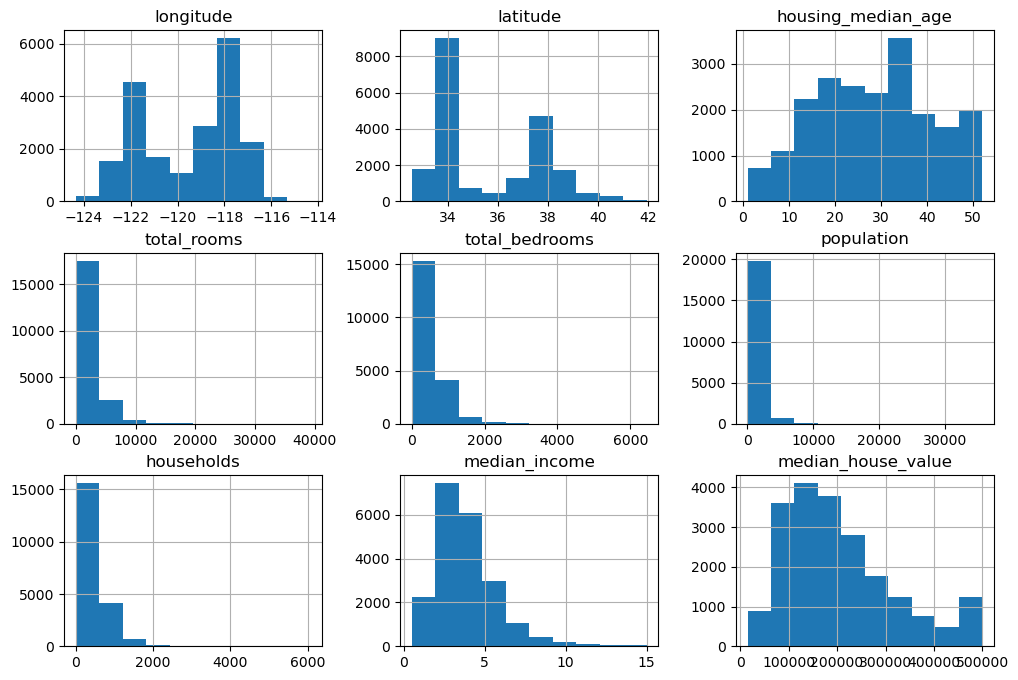

In [48]:
import matplotlib.pyplot as plt
housing.hist(figsize=(12,8))
plt.show()

[9683. 9088. 1488.  271.  110.] [ 0.4999   3.39994  6.29998  9.20002 12.10006 15.0001 ]


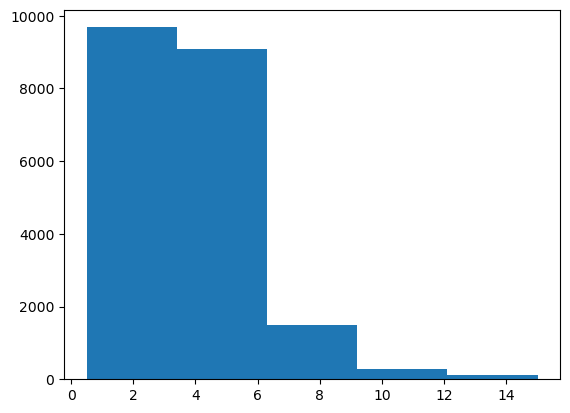

In [49]:
hists = plt.hist(housing['median_income'],bins=5)
print(hists[0],hists[1])
housing['income_cat'] =  pd.cut(housing['median_income'],bins=hists[1], labels=[1,2,3,4,5])
plt.show()

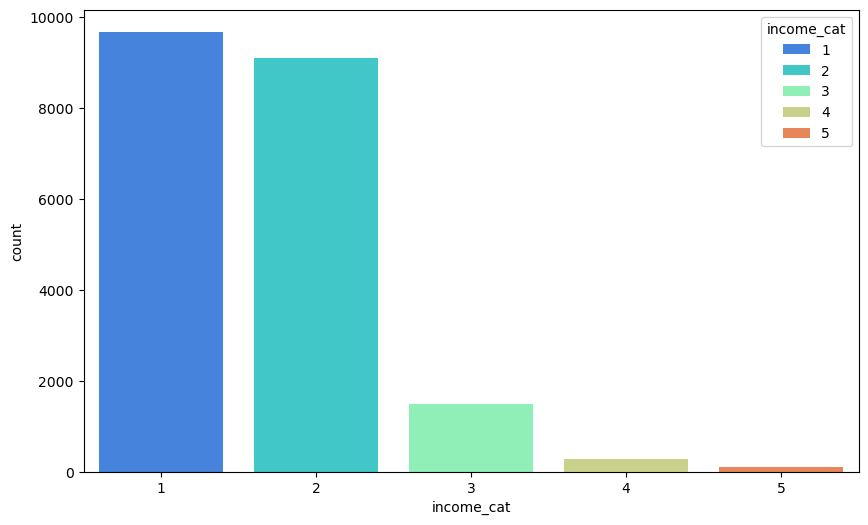

In [50]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=housing,x='income_cat',ax=ax,palette='rainbow',hue='income_cat')
plt.show()

In [51]:
housing.dropna(inplace=True)

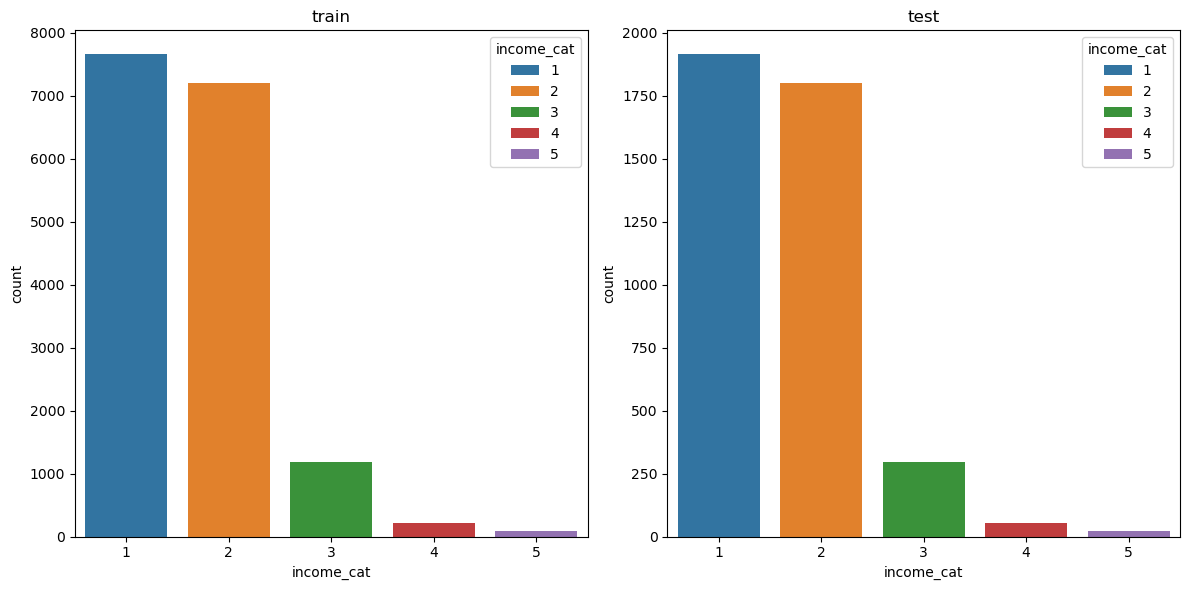

In [52]:
from sklearn.model_selection import  train_test_split
train,test = train_test_split(housing,test_size=0.2,random_state=42,
                              stratify=housing['income_cat']
                              )
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].set_title('train')
axes[1].set_title('test')
sns.countplot(data=train, x='income_cat',hue='income_cat',ax=axes[0])
sns.countplot(data=test, x='income_cat',hue='income_cat',ax=axes[1])
plt.tight_layout()
plt.show()

In [54]:
housing['income_cat'].value_counts()

income_cat
1    9569
2    9001
3    1475
4     267
5     109
Name: count, dtype: int64